# Robust Regression — Huber Loss

---

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

is the feature vector and

$$
y_i \in \mathbb{R}
$$

is the target value.  

The goal is to learn a regression model that is **robust to outliers** in $y$.

---

## 2. Linear Model

We assume a linear model:

$$
\hat{y}_i = w^T x_i
$$

where

$$
w \in \mathbb{R}^D
$$

is the weight vector.

---

## 3. Adding the Bias Term

To include an intercept, we augment the feature vector:

$$
x_i \gets 
\begin{bmatrix}
1 \\
x_i
\end{bmatrix}
$$

and the weight vector becomes

$$
w \gets 
\begin{bmatrix}
b \\
w
\end{bmatrix}
$$

Then the prediction is:

$$
\hat{y}_i = w^T x_i
$$

---

## 4. Residuals

The residual for each sample is:

$$
r_i = y_i - \hat{y}_i
$$

---

## 5. Huber Loss Function

The Huber loss combines squared error and absolute error to be robust to outliers:

$$
L_\delta(r_i) =
\begin{cases}
\frac{1}{2} r_i^2 & \text{if } |r_i| \le \delta \\
\delta \left(|r_i| - \frac{1}{2} \delta \right) & \text{if } |r_i| > \delta
\end{cases}
$$

where $\delta > 0$ is a threshold parameter controlling robustness:

- Smaller $\delta$ → more resistant to outliers
- Larger $\delta$ → behaves like standard linear regression

---

## 6. Full Objective Function

The total Huber loss over the dataset is:

$$
J(w) = \frac{1}{N} \sum_{i=1}^{N} L_\delta(r_i)
$$

---

## 7. Huber Gradient

The gradient of the Huber loss w.r.t. $w$ for a residual $r_i$ is:

$$
\nabla_w L_\delta(r_i) =
\begin{cases}
- r_i x_i & \text{if } |r_i| \le \delta \\
- \delta \, \text{sign}(r_i) \, x_i & \text{if } |r_i| > \delta
\end{cases}
$$

Vectorized for a batch of size $B$:

$$
g = \frac{1}{B} \sum_{i \in \text{batch}} \nabla_w L_\delta(r_i)
$$

---

## 8. Momentum Update

To accelerate convergence, we use momentum:

$$
v \gets \beta v + (1-\beta) g
$$

where $\beta \in [0,1)$ is the momentum coefficient.

---

## 9. Weight Update

Weights are updated using the momentum:

$$
w \gets w - \alpha v
$$

where $\alpha > 0$ is the learning rate.

---

## 10. Mini-batch Gradient Descent

For each epoch:

1. Shuffle the dataset.
2. Split into mini-batches of size $B$.
3. For each batch:
    - Compute predictions $\hat{y}_i = w^T x_i$
    - Compute residuals $r_i = y_i - \hat{y}_i$
    - Compute gradient $g$ from Huber loss
    - Update momentum $v$ and weights $w$

---

## 11. Full Loss Monitoring

After each epoch, compute the full Huber loss:

$$
J(w) = \frac{1}{N} \sum_{i=1}^{N} L_\delta(y_i - w^T x_i)
$$

Stop early if:

$$
|J(w_\text{current}) - J(w_\text{previous})| < \text{tol}
$$

where `tol` is a small positive threshold.

---

## 12. Prediction

Given a new input $x_\text{new}$:

$$
\hat{y}_\text{new} = w^T x_\text{new}
$$

---

## 13. Key Points

- Huber loss interpolates between **MSE** (for small residuals) and **MAE** (for large residuals).  
- Delta $\delta$ controls **robustness**:  
  - Small δ → more robust to outliers  
  - Large δ → behaves like standard linear regression  
- Momentum improves **convergence speed**.  
- Mini-batch gradient descent allows scaling to **large datasets**.

---

## 14. Algorithm Summary

**Initialize:**

$$
w = 0, \quad v = 0
$$

**Repeat for each epoch:**

1. Shuffle data
2. For each mini-batch:
   - Compute predictions $\hat{y}$
   - Compute residuals $r$
   - Compute Huber gradient $g$
   - Update momentum $v$
   - Update weights $w$
3. Compute full Huber loss and check stopping criterion

In [1]:
class RobustRegressor:
    """
    Robust Regressor using Huber Loss with mini-batch gradient descent and momentum.

    Parameters
    ----------
    delta : float, default=0.1
        Threshold for Huber loss. Smaller delta → more robust to outliers.
    beta : float, default=0.9
        Momentum coefficient. Should be in [0,1).
    alpha : float, default=0.01
        Learning rate for gradient updates.
    add_bias : bool, default=True
        Whether to add a bias (intercept) term to the input features.
    batch_size : int, default=10
        Number of samples per mini-batch.
    epochs : int, default=100
        Maximum number of epochs for training.
    tol : float, default=0.01
        Early stopping tolerance for loss improvement.
    """

    def __init__(self,delta=0.1,beta=0.9,alpha=0.01,add_bias=True,batch_size=10,epochs=100, tol=0.01):
        # Parameter Validation 
        self.delta= delta
        if self.delta <0 :
            raise ValueError('Delta has to be greater than or equal to 0')
        
        self.beta = beta
        if self.beta <0 or self.beta >=1:
            raise ValueError('beta has to be less than 1 and greater than 0')
        
        self.alpha = alpha
        if self.alpha <=0 :
            raise ValueError('Alpha has to be greater than 0')
            
        self.add_bias = add_bias
      
        self.batch_size = batch_size
        
        if type(self.batch_size) != int or  self.batch_size <=0:
            raise ValueError('Batch Size has to be natural number')        
        self.epochs=epochs
        
        if type(self.epochs) != int or  self.epochs <=0:
            raise ValueError('Epochs have to be natural number')
        self.tol = tol

        # Model Parameters
        self.weights = None
        self.momentum = None


    def _shuffle_indices(self,N):
        """
        Shuffle indices for creating mini-batches.
        """
 
        indices = np.arange(N)

        np.random.shuffle(indices)

        return indices


    def _batch_generator(self, shuffled_indices,batch_size):
        """
        Generator that yields batches of indices.
        """


        for start in range(0,len(shuffled_indices),batch_size):
            index = shuffled_indices[start : start+batch_size]

            yield index


    def _huber_gradient(self,residual):
        """
        Compute the Huber gradient for a vector of residuals.

        For |r| <= delta: gradient = -r
        For |r| > delta: gradient = -delta * sign(r)
        """
 
        abs_r = np.abs(residual)
        sign_r = np.sign(residual)


        return np.where(abs_r <= self.delta , -residual , -self.delta * sign_r)


    def _huber_loss(self, full_residual):
        """
        Compute Huber loss for a vector of residuals.
        """

        abs_r = np.abs(full_residual)

        
        return np.where(abs_r <= self.delta , 0.5 * (full_residual**2) , self.delta* (abs_r-0.5 * self.delta) )



    def fit(self,X,y):
        """
        Fit the robust regressor to the data using mini-batch gradient descent with momentum.
        """

        X = np.asarray(X)
        y = np.asarray(y)

        y= y.reshape(-1)
        
        # Convert 1D X to 2D
        if X.ndim==1:
            X = X.reshape(-1,1)


        N , D = X.shape
        
        # Add bias term if requested
        if self.add_bias:
            X = np.column_stack((np.ones(N),X))
            D +=1

            
        # Initialize weights and momentum
        self.weights= np.zeros(D)
        self.momentum = np.zeros(D)

        loss_previous = np.inf

        for i in range(self.epochs):
            # Shuffle data at the start of each epoch
            shuffled_indices = self._shuffle_indices(N)

            batch_indices = self._batch_generator(shuffled_indices,self.batch_size)
            
            # Mini-batch gradient descent
            while True :
                try:
                    indices = next(batch_indices)
                except StopIteration:
                    break
                    
                X_batch , y_batch = X[indices] , y[indices]
                y_hat = X_batch @ self.weights

                residuals = y_batch - y_hat
                
                # Compute gradient for Huber loss
                huber_gradient = self._huber_gradient(residuals)

                # Update momentum and weights
                gradient = (X_batch.T @ huber_gradient) / len(indices)

                
                
                self.momentum = self.beta * self.momentum + (1-self.beta) * gradient

                self.weights -=  self.alpha *  self.momentum 


            whole_residual = y - X @ self.weights
            
            # Compute full Huber loss to monitor convergence
            loss_current = np.mean(self._huber_loss(whole_residual))
            
            # Early stopping
            if abs(loss_current - loss_previous) < self.tol:
                print(f"Stopping early at epoch {i}: improvement < {self.tol}")
                break


            loss_previous = loss_current

    def predict(self,X):
        """
        Predict target values for given input features.
        """
        X = np.asarray(X)

        # Convert 1D X to 2D
        if X.ndim==1:
            X = X.reshape(-1,1)


        N = len(X)

        # Add bias term if used
        if self.add_bias :
            X = np.column_stack((np.ones(N),X))

        return X @ self.weights
 

## Robust Regression Experiment: Comparison with Linear Regression


### 1. Experiment Setup

- Generate synthetic data with 3 features and 500 samples.
- True weights: `true_w = [2.0, -3.0, 1.5]`.
- Add Gaussian noise with standard deviation 0.5.
- Inject 25 strong outliers in the target variable `y`.

---

In [2]:
import numpy as np
import pandas as pd

# Generate Data (with OUTLIERS)

np.random.seed(42)

N = 500
D = 3

true_w = np.array([2.0, -3.0, 1.5])

X = np.random.randn(N, D)
y = X @ true_w + np.random.randn(N)*0.5

# Inject outliers
outliers = np.random.choice(N, 25, replace=False)
y[outliers] += np.random.randn(25)*20

In [3]:
# Closed Form Linear Regression

w_closed = np.linalg.inv(X.T @ X) @ X.T @ y
print(f'The closed form weights are: {w_closed}')

The closed form weights are: [ 2.32304288 -3.1792021   1.52387795]


In [4]:
# Models

# Robust
robust = RobustRegressor(delta=1.0, alpha=0.01, epochs=2000, batch_size=50 ,add_bias=False , tol=1e-5)
robust.fit(X, y)

# Linear-like (large delta)
large_delta = RobustRegressor(delta=1e6, alpha=0.01, epochs=2000, batch_size=50,add_bias=False, tol=1e-5)
large_delta.fit(X, y)


Stopping early at epoch 89: improvement < 1e-05
Stopping early at epoch 40: improvement < 1e-05


In [5]:
true_w = np.array([2.0, -3.0, 1.5])

df = pd.DataFrame({
    "Model": [
        "True Weights",
        "Closed Form", 
        "Robust (delta=1)", 
        "Huber (large δ)", 
      
    ],
    
    "Weights": [
        np.round(true_w, 3),
        np.round(w_closed, 3),
        np.round(robust.weights, 3),
        np.round(large_delta.weights, 3)
    ]
})


print(df)

              Model                 Weights
0      True Weights        [2.0, -3.0, 1.5]
1       Closed Form  [2.323, -3.179, 1.524]
2  Robust (delta=1)  [1.992, -3.015, 1.477]
3   Huber (large δ)  [2.285, -3.137, 1.511]


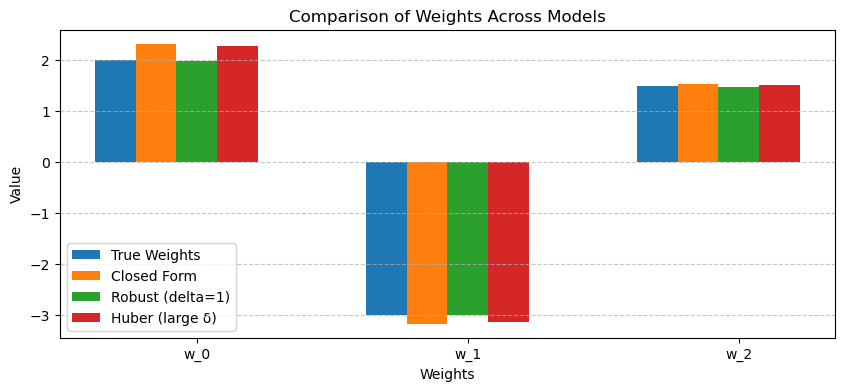

In [6]:
import matplotlib.pyplot as plt

# Prepare data for plotting
models = ["True Weights", "Closed Form", "Robust (delta=1)", "Huber (large δ)"]
weights_list = [
    true_w,
    w_closed,
    robust.weights,
    large_delta.weights,
]

weights_array = np.array(weights_list)

x = np.arange(D)  # feature indices

plt.figure(figsize=(10,4))
bar_width = 0.15

# Plot each model's weights with a small offset
for i, model in enumerate(models):
    plt.bar(x + i*bar_width, weights_array[i].round(3), width=bar_width, label=model)

plt.xticks(x + 2*bar_width, [f'w_{i}' for i in range(D)])
plt.xlabel("Weights")
plt.ylabel("Value")
plt.title("Comparison of Weights Across Models")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---

### 2. Observations

- **Robust Regressor** weights are closer to the true weights even in the presence of outliers.  
- **Standard Linear Regression (Closed Form)** weights are biased due to outliers.  
- **Huber Regressor with large δ** behaves more like standard linear regression.  

---
### 3. Delta Parameter Insights

- **Smaller delta** → more resistant to outliers, prioritizes robustness.  
- **Larger delta** → behaves more like standard linear regression, less robust to outliers.  

---


### 4. Delta Parameter Insights

- **Smaller delta** → more resistant to outliers, prioritizes robustness.  
- **Larger delta** → behaves more like standard linear regression, less robust to outliers.

---
